In [106]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [204]:
# Parameters
N_s   = 30
beta = 0.1
global_inhibition = 0.2
width = 0.2
v = 0.5
dt = 0.1
L = 1000
target = 0
sigma = 0.4
kappa = 20
u = 1

psi1 = 0.0
gamma1 = 5.0
psi2 = np.pi / 2
gamma2 = 3.0
psi3 = np.pi * 3/2
gamma3 = 8

targets = np.array([psi1, psi2, psi3])
#targets = np.array([psi1])

gammas = np.array([gamma1, gamma2, gamma3])
#gammas = np.array([gamma1])




In [ ]:
# Node positions and connectivity
theta = np.array([2*np.pi*i/N_s for i in range(N_s)])

M = np.zeros((N_s, N_s))
for i in range(N_s):
    for j in range(N_s):          
        angular_diff = np.arctan2(np.sin(theta[i] - theta[j]), np.cos(theta[i] - theta[j]))
        M[i, j] = np.cos(np.pi * np.power(np.abs(angular_diff), v) / np.pi) * (1/N_s) #abs not right?


[ 0.03333333  0.02990317  0.02659233  0.02339831  0.02031866  0.01735094
  0.01449279  0.01174185  0.0090958   0.00655237  0.00410931  0.00176443
 -0.00048447 -0.00263951 -0.00470282 -0.00667645 -0.00470282 -0.00263951
 -0.00048447  0.00176443  0.00410931  0.00655237  0.0090958   0.01174185
  0.01449279  0.01735094  0.02031866  0.02339831  0.02659233  0.02990317]
[0.34164321 0.34164321 0.34164321 0.34164321 0.34164321 0.34164321
 0.34164321 0.34164321 0.34164321 0.34164321 0.34164321 0.34164321
 0.34164321 0.34164321 0.34164321 0.34164321 0.34164321 0.34164321
 0.34164321 0.34164321 0.34164321 0.34164321 0.34164321 0.34164321
 0.34164321 0.34164321 0.34164321 0.34164321 0.34164321 0.34164321]


In [208]:
#Helper functions
def plot_ring(z, theta, name):
    firing_rate  = z
    theta_closed = np.append(theta, theta[0])
    fr_closed    = np.append(z, z[0])

    r_base = 0
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})
    #ax.fill_between(theta_closed, r_base, r_base + fr_closed * 0.4, color='blue')
    #ax.plot(theta_closed, r_base + fr_closed * 0.4, color='blue', linewidth=1.5)
    #ax.fill_between(theta_closed, r_base, r_base + fr_closed * 0.4, alpha=0.4, color='blue')
    ax.plot(theta_closed, np.maximum(fr_closed, 0.2), color='blue')

    ax.set_ylim(0, 2.0)
    ax.set_title(f'Firing rate of {name} around the ring')
    plt.tight_layout()
    plt.show()

def find_centre_off_mass(weights, angles):
    com = np.zeros(2)
    weighted_sum = np.zeros(2)
    total_weights = 0

    for i in range(len(weights)):
        weighted_sum += np.array([weights[i] * np.cos(angles[i]), weights[i] * np.sin(angles[i])])
        total_weights += weights[i]

    com = weighted_sum/total_weights

    return com


t=0, max z=0.0000, min z=0.0000
t=20, max z=0.6560, min z=-0.1981
t=40, max z=0.7399, min z=-0.2339
t=60, max z=0.7508, min z=-0.2406
t=80, max z=0.7523, min z=-0.2418
t=100, max z=0.7525, min z=-0.2421
t=120, max z=0.7525, min z=-0.2421
t=140, max z=0.7525, min z=-0.2421
t=160, max z=0.7526, min z=-0.2421
t=180, max z=0.7526, min z=-0.2421
[ 6.03460455e-01  3.94760359e-01  2.36292187e-03 -1.51628688e-01
 -1.79423139e-01 -1.57885338e-01 -7.24318935e-04  2.58833310e-01
  2.51828693e-01 -2.45358657e-02 -1.97433187e-01 -2.35094924e-01
 -2.40679379e-01 -2.42115793e-01 -2.41604779e-01 -2.37847265e-01
 -2.30100707e-01 -2.19172191e-01 -2.06252087e-01 -1.84594243e-01
 -7.88254440e-02  3.49669383e-01  7.50345089e-01  7.52550405e-01
  3.68593213e-01 -3.91199849e-02 -1.28466578e-01 -1.16718676e-01
  2.53957575e-02  4.03558037e-01]


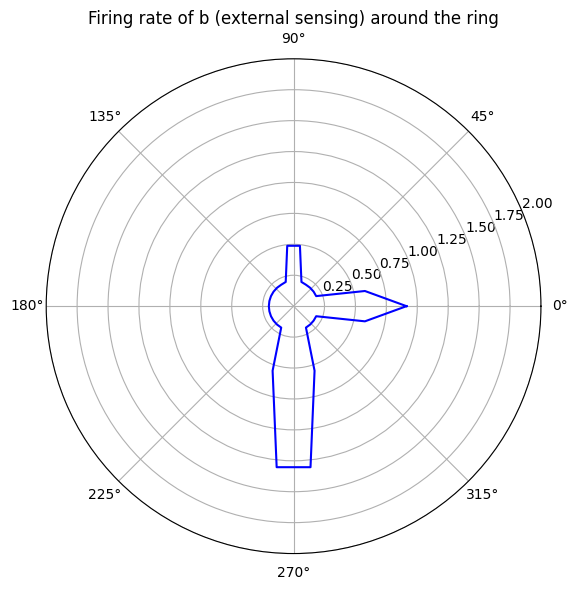

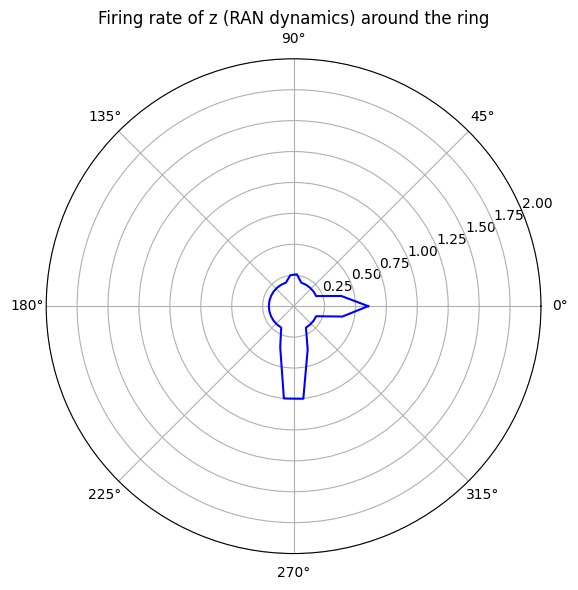

In [ ]:
# Static RAN run
z      = np.zeros(N_s)
z_next = np.zeros(N_s)
T      = 200

b = np.zeros(N_s)

for j in range(len(targets)):
    for i in range(N_s):
        angular_diff = np.arctan2(np.sin(theta[i] - targets[j]), np.cos(theta[i] - targets[j]))
        b[i] += (1/np.sqrt(N_s)) * np.exp(kappa * (np.cos(angular_diff) - 1.0)) * gammas[j]


for t in range(T):
    if t % 20 == 0:
        print(f"t={t}, max z={z.max():.4f}, min z={z.min():.4f}")

    z_next = z + dt * (-z + np.tanh(u * (M @ z) + b - beta) - np.tanh(beta))
    #z_next = z + dt * (-z + np.tanh(u * (M @ z) + b - beta))
    z[:] = z_next

print(z)
vel_vec = find_centre_off_mass(z, theta)

plot_ring(b, theta, "b (external sensing)")
plot_ring(z, theta, "z (RAN dynamics)")

In [199]:
# Warm up network to settled bump state before recording
u      = np.zeros(N_s)
z_next = np.zeros(N_s)
b    = np.zeros(N_s)

for _ in range(500):
    h = np.zeros(N_s)
    for i in range(N_s):
        angular_diff = np.arctan2(np.sin(theta[i] - target), np.cos(theta[i] - target))
        h[i] = (b / np.sqrt(2 * np.pi * sigma**2)) * np.exp(-angular_diff**2 / (2 * sigma**2))
    for i in range(N_s):
        excitation_term = 0
        for j in range(N_s):
            excitation_term += M[i][j] * np.tanh(beta * u[j])
        z_next[i] = u[i] + dt * (-u[i] + (1/N_s) * excitation_term - h_b + h[i])
    u[:] = z_next

# Pre-compute all animation frames from settled state
frames = []
for t in range(150):
    if (t > 60):
        moving_target = ((150 - t / 100) % (2 * np.pi))
    else:
        moving_target = (t / 100) % (2 * np.pi)

    h = np.zeros(N_s)
    for i in range(N_s):
        angular_diff = np.arctan2(np.sin(theta[i] - moving_target), np.cos(theta[i] - moving_target))
        h[i] = (b / np.sqrt(2 * np.pi * sigma**2)) * np.exp(-angular_diff**2 / (2 * sigma**2))
    for i in range(N_s):
        excitation_term = 0
        for j in range(N_s):
            excitation_term += M[i][j] * np.tanh(beta * u[j])
        z_next[i] = u[i] + dt * (-u[i] + (1/N_s) * excitation_term - h_b + h[i])
    u[:] = z_next
    frames.append(np.maximum(0, np.tanh(beta * u.copy())))

from matplotlib.animation import PillowWriter
from IPython.display import Image

r_base       = 0.5
theta_closed = np.append(theta, theta[0])

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={'projection': 'polar'})
fr0  = np.append(frames[0], frames[0][0])
fill = [ax.fill_between(theta_closed, r_base, r_base + fr0 * 0.4, theta=0.4, color='blue')]
line, = ax.plot(theta_closed, r_base + fr0 * 0.4, color='blue', linewidth=1.5)
ax.set_ylim(0, 1.1)
ax.set_yticks([])
ax.set_title('Firing rate around the ring')

writer = PillowWriter(fps=20)
with writer.saving(fig, 'ran_animation.gif', dpi=80):
    for frame_data in frames:
        fill[0].remove()
        fr = np.append(frame_data, frame_data[0])
        fill[0] = ax.fill_between(theta_closed, r_base, r_base + fr * 0.4, theta=0.4, color='blue')
        line.set_ydata(r_base + fr * 0.4)
        writer.grab_frame()

plt.close()
Image('ran_animation.gif')

ValueError: setting an array element with a sequence.